# Language Translation Analysis using GPT-4o

This notebook analyzes token count changes when translating medical text from English to different langauges using OpenAI's GPT-4o model.
Languages: Spanish, Chinese, Tagalog, Vietnamese

**Goal**: Understand and quantify the token increase phenomenon across different sentence complexities and batches.

In [18]:
import xml.etree.ElementTree as ET
import os
from getpass import getpass
from openai import OpenAI
import json
import tiktoken

# Initialize OpenAI client.
# If OPENAI_API_KEY is not available in this notebook kernel, prompt once.
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    api_key = getpass("Enter OPENAI_API_KEY: ").strip()

client = OpenAI(api_key=api_key)

# Initialize tokenizer for GPT-4o (o200k_base)
encoding = tiktoken.get_encoding("o200k_base")

In [19]:
def extract_questions(folder_path, max_q=30):
    """Extract questions from MedQuAD XML files"""
    questions = []
    for root_dir, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".xml"):
                try:
                    tree = ET.parse(os.path.join(root_dir, file))
                    root = tree.getroot()
                    for qa in root.findall(".//QAPair"):
                        q = qa.find("Question")
                        if q is not None and q.text:
                            questions.append(q.text)
                        if len(questions) >= max_q:
                            return questions
                except:
                    pass
    return questions

def add_clinical_sentences():
    """Add realistic clinical-style sentences"""
    return [
        "The patient presented with acute myocardial infarction and elevated troponin levels.",
        "Magnetic resonance imaging revealed a herniated intervertebral disc at L4-L5.",
        "The hematology panel indicated microcytic anemia with hemoglobin of 7.2 g/dL.",
        "Renal function tests showed creatinine of 2.5 mg/dL with estimated GFR of 28.",
        "The chest X-ray demonstrated bilateral pneumonia with consolidation in both lower lobes.",
    ]

def classify_complexity(sentence):
    """Classify sentence as simple (<50 chars) or complex (>=50 chars)"""
    return "simple" if len(sentence) < 50 else "complex"

def count_tokens_for_text(text):
    """Count tokens using o200k_base encoding"""
    return len(encoding.encode(text))

In [20]:
def translate_and_count_tokens(sentences, target_language, batch_size=10):
    """Translate sentences to a target language in batches and analyze token changes"""
    all_results = []
    batch_stats = []
    
    print(f"\n--- Processing for {target_language} ---")
    
    for batch_num, i in enumerate(range(0, len(sentences), batch_size), 1):
        batch = sentences[i:i+batch_size]
        text_to_translate = "\n".join(batch)
        
        # Count tokens for English sentences (per-sentence + total)
        english_tokens_per_sentence = [count_tokens_for_text(s) for s in batch]
        english_tokens_total = sum(english_tokens_per_sentence)
        
        # Translate using GPT-4o
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "system",
                    "content": f"Translate the following English text to {target_language}. Maintain medical terminology accuracy."
                },
                {
                    "role": "user",
                    "content": text_to_translate
                }
            ]
        )
        
        translated_text = response.choices[0].message.content
        translated_sentences = translated_text.split("\n")
        
        # Count tokens for translated sentences (per-sentence + total)
        translated_tokens_per_sentence = [count_tokens_for_text(s) for s in translated_sentences if s.strip()]
        translated_tokens_total = sum(translated_tokens_per_sentence)
        
        # Per-sentence analysis
        batch_results = []
        for j, (en_sent, trans_sent) in enumerate(zip(batch, translated_sentences)):
            if j < len(translated_tokens_per_sentence):
                en_tokens = english_tokens_per_sentence[j]
                trans_tokens = translated_tokens_per_sentence[j]
                token_change = trans_tokens - en_tokens
                pct_change = (token_change / en_tokens * 100) if en_tokens > 0 else 0
                
                batch_results.append({
                    "sentence_num": i + j + 1,
                    "language": target_language,
                    "batch": batch_num,
                    "english_text": en_sent,
                    "translated_text": trans_sent.strip(),
                    "complexity": classify_complexity(en_sent),
                    "english_tokens": en_tokens,
                    "translated_tokens": trans_tokens,
                    "token_change": token_change,
                    "pct_change": round(pct_change, 2)
                })
        
        # Batch statistics
        ratio = translated_tokens_total / english_tokens_total if english_tokens_total > 0 else 0
        batch_stat = {
            "language": target_language,
            "batch": batch_num,
            "sentence_count": len(batch),
            "english_tokens_total": english_tokens_total,
            "translated_tokens_total": translated_tokens_total,
            "token_change": translated_tokens_total - english_tokens_total,
            "ratio": round(ratio, 3),
            "pct_change": round((translated_tokens_total - english_tokens_total) / english_tokens_total * 100, 2)
        }
        
        batch_stats.append(batch_stat)
        all_results.extend(batch_results)
        
        print(f"Batch {batch_num}: EN={english_tokens_total} → {target_language[:3].upper()}={translated_tokens_total} (ratio: {ratio:.3f}, {batch_stat['pct_change']:+.1f}%)")
    
    return all_results, batch_stats

In [21]:
# Define the languages to analyze
target_languages = ["Spanish", "Chinese", "Tagalog", "Vietnamese"]
all_language_results = []
all_language_batch_stats = []

# Extract questions (30 samples for trial)
print("Extracting questions from MedQuAD...")
questions = extract_questions("Dataset_MedQuAD", max_q=30)
print(f"Extracted {len(questions)} questions")

# Add clinical sentences
print("\nAdding clinical sentences...")
clinical = add_clinical_sentences()
all_sentences = questions + clinical
print(f"Total sentences: {len(all_sentences)}")

# Loop through each language and perform the analysis
for lang in target_languages:
    results, batch_stats = translate_and_count_tokens(all_sentences, lang, batch_size=10)
    all_language_results.extend(results)
    all_language_batch_stats.extend(batch_stats)

# Create a single DataFrame with all results
res_df = pd.DataFrame(all_language_results)

Extracting questions from MedQuAD...
Extracted 30 questions

Adding clinical sentences...
Total sentences: 35

--- Processing for Spanish ---
Batch 1: EN=137 → SPA=178 (ratio: 1.299, +29.9%)
Batch 2: EN=96 → SPA=120 (ratio: 1.250, +25.0%)
Batch 3: EN=92 → SPA=115 (ratio: 1.250, +25.0%)
Batch 4: EN=93 → SPA=117 (ratio: 1.258, +25.8%)

--- Processing for Chinese ---
Batch 1: EN=137 → CHI=94 (ratio: 0.686, -31.4%)
Batch 2: EN=96 → CHI=94 (ratio: 0.979, -2.1%)
Batch 3: EN=92 → CHI=96 (ratio: 1.043, +4.3%)
Batch 4: EN=93 → CHI=112 (ratio: 1.204, +20.4%)

--- Processing for Tagalog ---
Batch 1: EN=137 → TAG=117 (ratio: 0.854, -14.6%)
Batch 2: EN=96 → TAG=124 (ratio: 1.292, +29.2%)
Batch 3: EN=92 → TAG=102 (ratio: 1.109, +10.9%)
Batch 4: EN=93 → TAG=124 (ratio: 1.333, +33.3%)

--- Processing for Vietnamese ---
Batch 1: EN=137 → VIE=214 (ratio: 1.562, +56.2%)
Batch 2: EN=96 → VIE=127 (ratio: 1.323, +32.3%)
Batch 3: EN=92 → VIE=127 (ratio: 1.380, +38.0%)
Batch 4: EN=93 → VIE=137 (ratio: 1.473, 

## Multi-Language Comparison

Comparison of token change metrics for Spanish, Chinese, Tagalog, and Vietnamese.

### 1. Overall Token Change by Language

Average per-sentence percent token change by language.

--- Overall Mean % Change by Language ---
language
Chinese       22.19
Spanish       48.03
Tagalog       43.44
Vietnamese    67.69
Name: pct_change, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\330529244.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='language', y='pct_change', data=res_df, estimator=lambda x: sum(x) / len(x), palette='viridis', capsize=0.1)


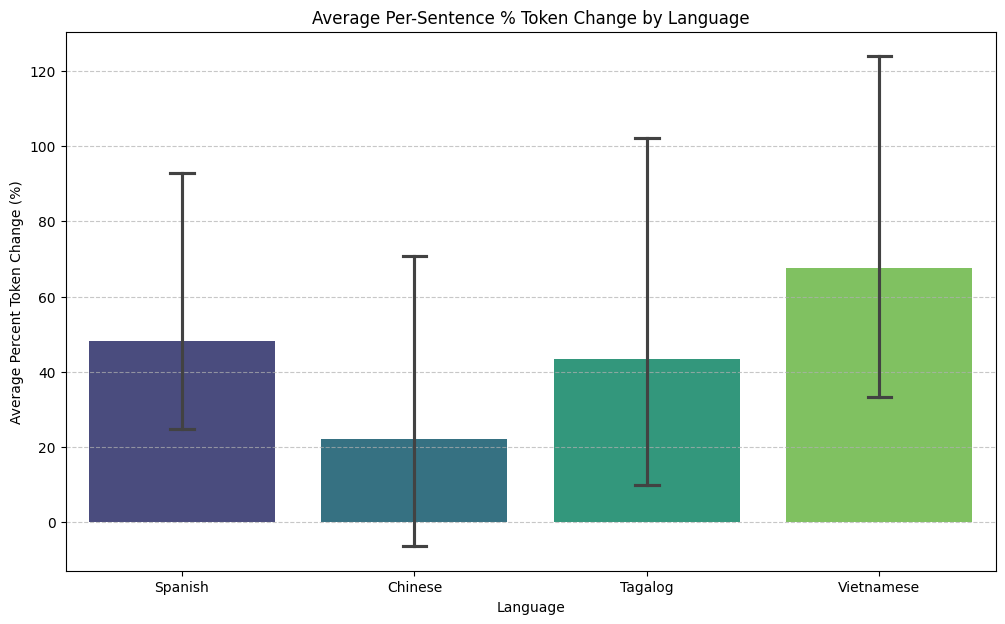

In [22]:
import seaborn as sns

# Overall summary
print("--- Overall Mean % Change by Language ---")
print(res_df.groupby('language')['pct_change'].mean().round(2))

# Plot overall comparison
plt.figure(figsize=(12, 7))
sns.barplot(x='language', y='pct_change', data=res_df, estimator=lambda x: sum(x) / len(x), palette='viridis', capsize=0.1)
plt.title('Average Per-Sentence % Token Change by Language')
plt.ylabel('Average Percent Token Change (%)')
plt.xlabel('Language')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Distribution of Token Change by Language

Per-sentence percent token change distribution for each language.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\3404758709.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='language', y='pct_change', data=res_df, palette='muted', showmeans=True)


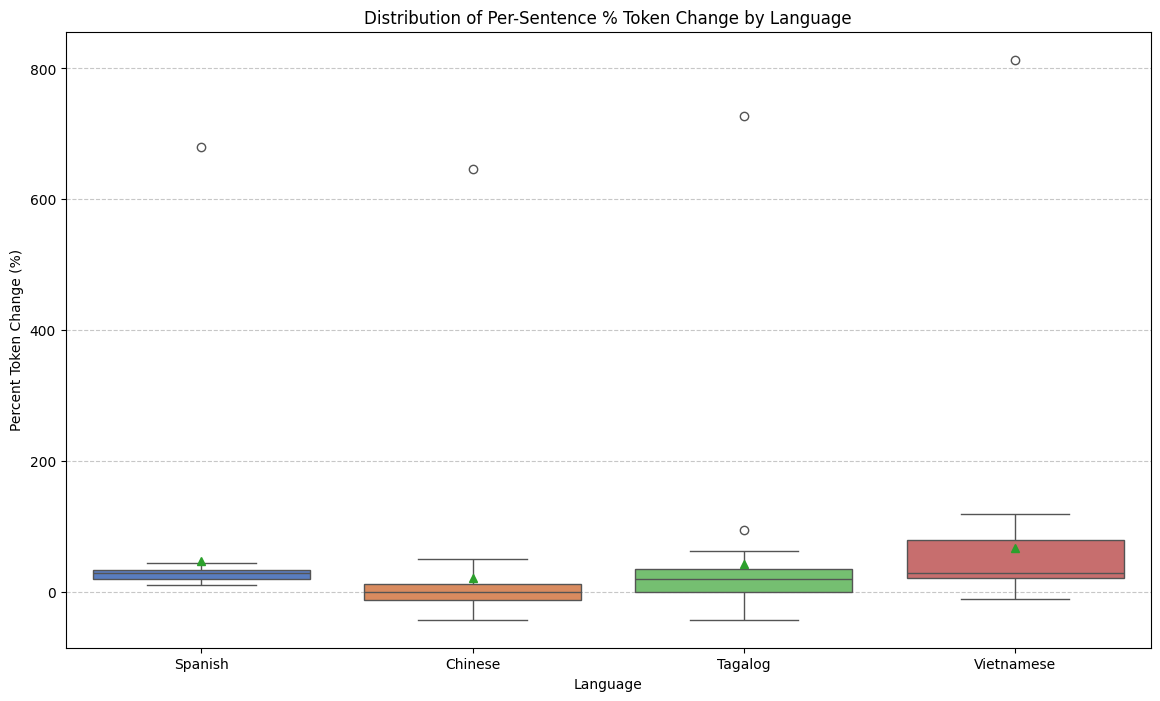

In [23]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='language', y='pct_change', data=res_df, palette='muted', showmeans=True)
plt.title('Distribution of Per-Sentence % Token Change by Language')
plt.ylabel('Percent Token Change (%)')
plt.xlabel('Language')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Complexity vs. Token Change Across Languages

Percent token change by language split by sentence complexity.

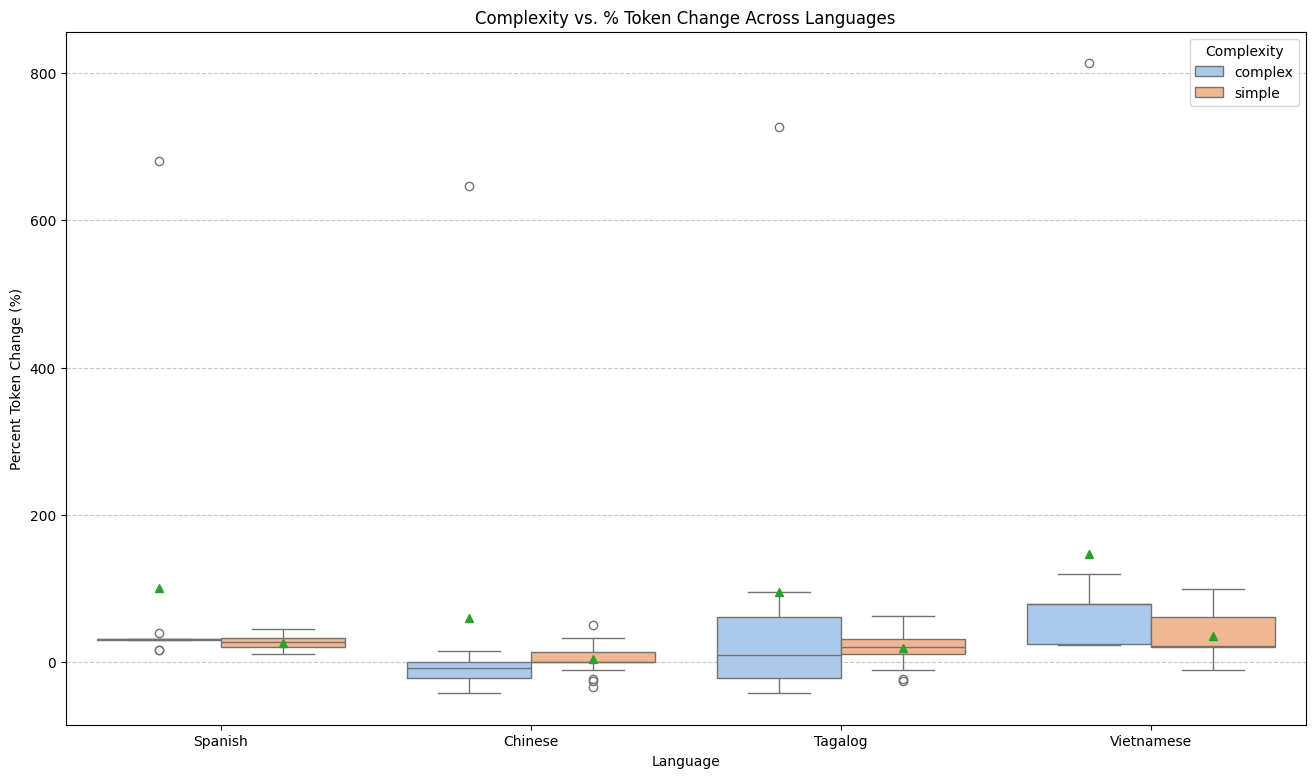

In [24]:
plt.figure(figsize=(16, 9))
sns.boxplot(x='language', y='pct_change', hue='complexity', data=res_df, palette='pastel', showmeans=True)
plt.title('Complexity vs. % Token Change Across Languages')
plt.ylabel('Percent Token Change (%)')
plt.xlabel('Language')
plt.legend(title='Complexity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Same Plots After Outlier Removal

The following plots repeat the same analysis using an outlier-filtered dataset.

In [25]:
import seaborn as sns


def remove_outliers_by_group(df, group_cols, value_col):
    def _filter_group(g):
        q1 = g[value_col].quantile(0.25)
        q3 = g[value_col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return g[(g[value_col] >= lower) & (g[value_col] <= upper)]

    return df.groupby(group_cols, group_keys=False).apply(_filter_group)


res_df_no_outliers = remove_outliers_by_group(
    res_df,
    group_cols=["language", "complexity"],
    value_col="pct_change",
)

print(f"Rows before: {len(res_df)}")
print(f"Rows after : {len(res_df_no_outliers)}")

Rows before: 118
Rows after : 105


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\1988175981.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(_filter_group)


### 1. Overall Token Change by Language (Outliers Removed)

--- Overall Mean % Change by Language (Outliers Removed) ---
language
Chinese        0.27
Spanish       27.24
Tagalog       21.47
Vietnamese    42.84
Name: pct_change, dtype: float64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\3071755847.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


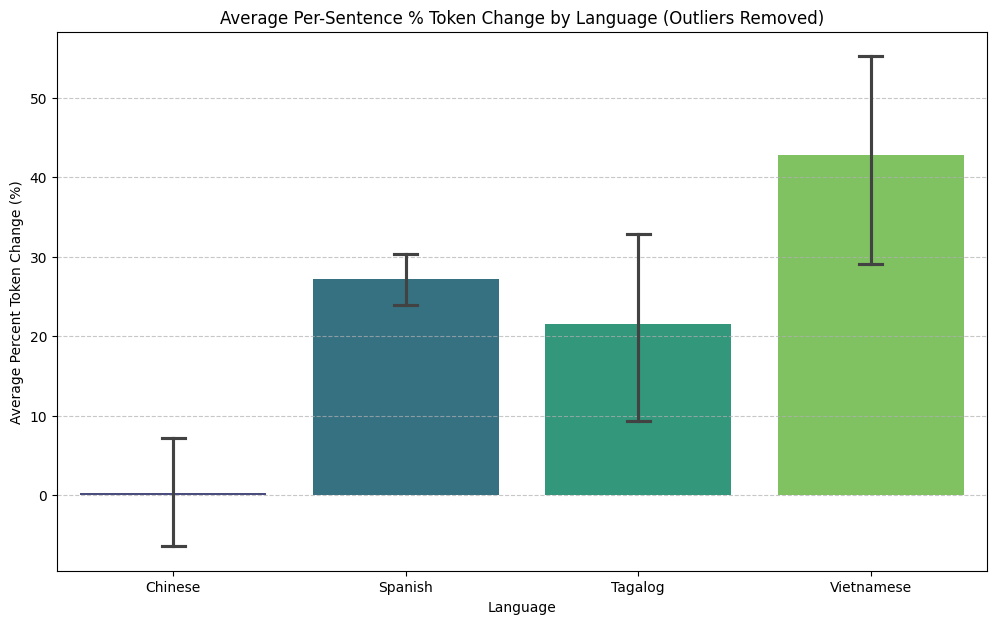

In [29]:
print("--- Overall Mean % Change by Language (Outliers Removed) ---")
print(res_df_no_outliers.groupby('language')['pct_change'].mean().round(2))

plt.figure(figsize=(12, 7))
sns.barplot(
    x='language',
    y='pct_change',
    data=res_df_no_outliers,
    estimator=lambda x: sum(x) / len(x),
    palette='viridis',
    capsize=0.1,
)
plt.title('Average Per-Sentence % Token Change by Language (Outliers Removed)')
plt.ylabel('Average Percent Token Change (%)')
plt.xlabel('Language')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Distribution of Token Change by Language (Outliers Removed)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16184\575132725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


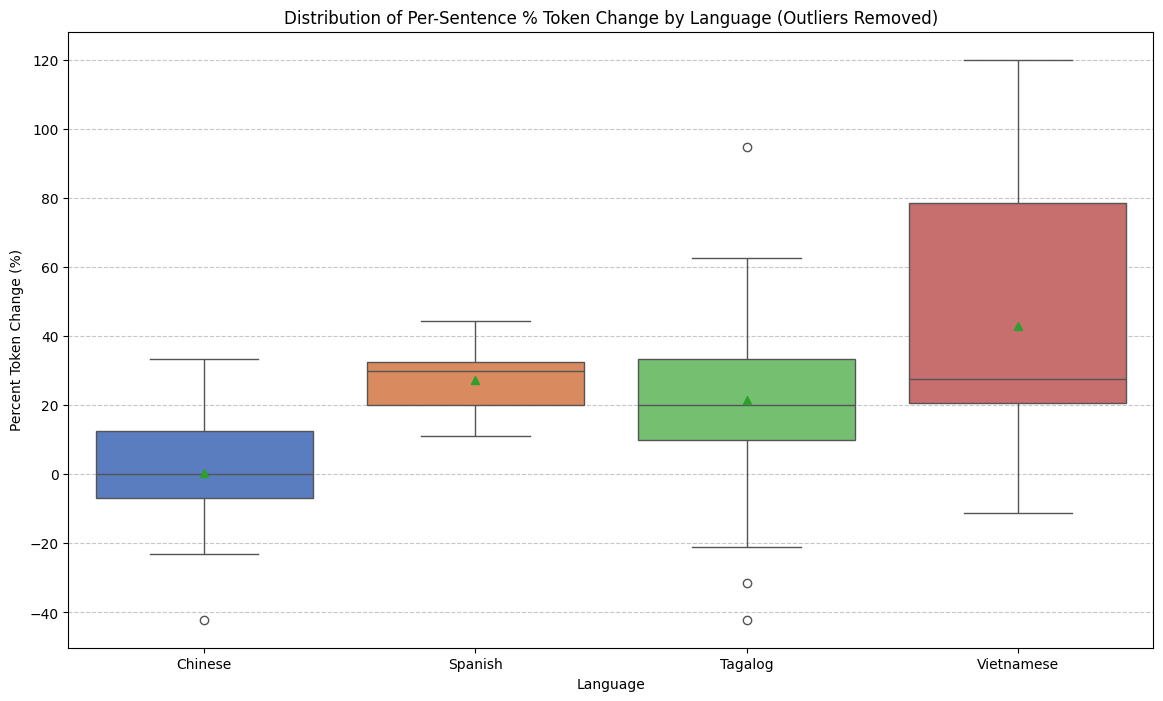

In [30]:
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='language',
    y='pct_change',
    data=res_df_no_outliers,
    palette='muted',
    showmeans=True,
)
plt.title('Distribution of Per-Sentence % Token Change by Language (Outliers Removed)')
plt.ylabel('Percent Token Change (%)')
plt.xlabel('Language')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Complexity vs. Token Change Across Languages (Outliers Removed)

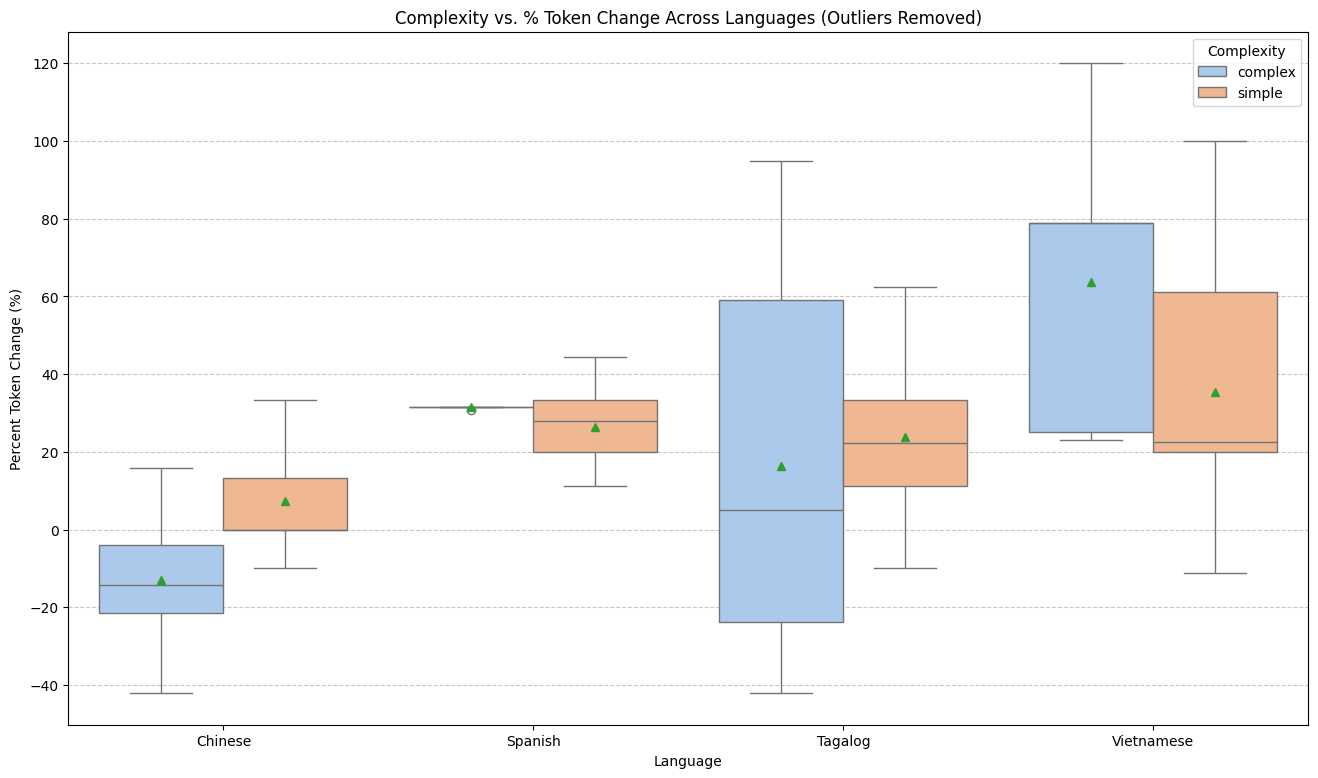

In [31]:
plt.figure(figsize=(16, 9))
sns.boxplot(
    x='language',
    y='pct_change',
    hue='complexity',
    data=res_df_no_outliers,
    palette='pastel',
    showmeans=True,
)
plt.title('Complexity vs. % Token Change Across Languages (Outliers Removed)')
plt.ylabel('Percent Token Change (%)')
plt.xlabel('Language')
plt.legend(title='Complexity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()